# EMsoftOO Python Binding Examples

This notebook demonstrates the `emsoft` Python package, which wraps the EMsoftOO Fortran library via ctypes.

**Before running:** ensure `EMSOFTOO_LIB` points to `EMsoftOO_c.dll`:
```
set EMSOFTOO_LIB=C:\...\build-ifx-release\Bin\EMsoftOO_c.dll
```

In [36]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## 1. Quaternions

Convention: **[w, x, y, z]** where `w` is the scalar part.  
Hamilton product with `epsijk = +1` (active rotations, EMsoftOO default).

In [37]:
from emsoft.quaternions import Quaternion, QuaternionArray

# Identity quaternion
q_id = Quaternion.identity()
print('identity:', q_id)

# 90-degree rotation around z-axis
angle = np.pi / 2
q_z90 = Quaternion(np.cos(angle/2), 0, 0, np.sin(angle/2))
print('90 deg @z:', q_z90)

# 120-degree rotation around [111]
ax = np.array([1, 1, 1]) / np.sqrt(3)
q_111 = Quaternion(np.cos(np.pi/3), *(ax * np.sin(np.pi/3)))
print('120 deg @[111]:', q_111)

identity: [1.000000, 0.000000, 0.000000, 0.000000]
90 deg @z: [0.707107, 0.000000, 0.000000, 0.707107]
120 deg @[111]: [0.500000, 0.500000, 0.500000, 0.500000]


In [38]:
# Arithmetic
q1 = Quaternion(1, 0, 0, 0)          # identity
q2 = Quaternion(0.5, 0.5, 0.5, 0.5) # 120 deg @[111]

q3 = q1 * q2                  # Hamilton product
qc = q2.conjugate()           # conjugate (= inverse for unit quaternion)
print('norm of q2:', q2.norm())
print('inner product q2·q2*:', q2.inner(qc))

# Scalar multiplication
q4 = 2.0 * q1
print('2 * identity norm:', q4.norm())

# Normalize back to unit length
q4.normalize()
print('after normalize:', q4.norm())

norm of q2: 1.0
inner product q2·q2*: -0.5
2 * identity norm: 2.0
after normalize: 1.0


In [39]:
# Vector rotation: v' = q v q*
q = Quaternion(np.cos(np.pi/4), 0, 0, np.sin(np.pi/4))  # 90 deg @z

v = [1.0, 0.0, 0.0]          # x-axis
vr = q.rotate(v)              # should rotate to [0, 1, 0]
print('rotate x by 90 deg @z:', np.round(vr, 10))

# Rotate many vectors at once
vecs = np.eye(3)              # x, y, z unit vectors
vr_all = q.rotate_vectors(vecs)
print('rotated unit vectors:\n', np.round(vr_all, 10))

rotate x by 90 deg @z: [0. 1. 0.]
rotated unit vectors:
 [[ 0.  1.  0.]
 [-1.  0.  0.]
 [ 0.  0.  1.]]


In [40]:
# QuaternionArray: operate on many quaternions at once
angles = np.linspace(0, 2*np.pi, 8, endpoint=False)
data = np.column_stack([
    np.cos(angles/2),
    np.zeros_like(angles),
    np.zeros_like(angles),
    np.sin(angles/2)
])
qa = QuaternionArray(data)    # 8 rotations around z-axis
print(f'QuaternionArray with {len(qa)} elements')

# Rotate the x-axis by each quaternion in the array
rotated = qa.rotate([1.0, 0.0, 0.0])  # shape (8, 3)
print('x-axis rotated by each quaternion:')
print(np.round(rotated, 6))

# Element-wise multiplication
qa2 = QuaternionArray(np.tile([1, 0, 0, 0], (8, 1)).astype(float))
qa3 = qa * qa2  # identity * qa = qa
print('\nAfter multiplying by identity array, first element:', qa3[0])

QuaternionArray with 8 elements
x-axis rotated by each quaternion:
[[ 1.        0.        0.      ]
 [ 0.707107  0.707107  0.      ]
 [ 0.        1.        0.      ]
 [-0.707107  0.707107  0.      ]
 [-1.        0.        0.      ]
 [-0.707107 -0.707107  0.      ]
 [-0.       -1.        0.      ]
 [ 0.707107 -0.707107  0.      ]]

After multiplying by identity array, first element: [1.000000, 0.000000, 0.000000, 0.000000]


---
## 2. Rotation Representations

Nine representations, all interconvertible via the EMsoftOO Fortran library.

In [41]:
from emsoft.rotations import Rotation

# Create from Euler angles (Bunge convention: phi1, Phi, phi2)
r = Rotation.from_euler(30, 45, 60, degrees=True)
print(r)

# Extract all representations
eu  = r.to_euler(degrees=True)
qu  = r.to_quaternion()
om  = r.to_matrix()
ax  = r.to_axisangle(degrees=True)
ro  = r.to_rodrigues()
ho  = r.to_homochoric()
cu  = r.to_cubochoric()

print(f'Euler (deg):    phi1={eu[0]:.4f}  Phi={eu[1]:.4f}  phi2={eu[2]:.4f}')
print(f'Quaternion:     {np.round(qu, 6)}')
print(f'Axis-angle:     axis={np.round(ax[:3], 4)}  angle={ax[3]:.4f} deg')
print(f'Rodrigues:      {np.round(ro, 6)}')
print(f'Homochoric:     {np.round(ho, 6)}')
print(f'Cubochoric:     {np.round(cu, 6)}')
print(f'Rotation matrix:\n{np.round(om, 6)}')

Rotation(euler_deg=[30.00, 45.00, 60.00])
Euler (deg):    phi1=30.0000  Phi=45.0000  phi2=60.0000
Quaternion:     [ 0.653281 -0.369644  0.099046 -0.653281]
Axis-angle:     axis=[-0.4882  0.1308 -0.8629]  angle=98.4211 deg
Rodrigues:      [-0.488227  0.13082  -0.862856  1.158942]
Homochoric:     [-0.399143  0.10695  -0.705417]
Cubochoric:     [-0.44167   0.131168 -0.658932]
Rotation matrix:
[[ 0.126826  0.78033   0.612372]
 [-0.926777 -0.126826  0.353553]
 [ 0.353553 -0.612372  0.707107]]


In [42]:
# Round-trip test: Euler -> quaternion -> matrix -> Euler
phi1, Phi, phi2 = 30.0, 45.0, 60.0
r1 = Rotation.from_euler(phi1, Phi, phi2, degrees=True)
q  = r1.to_quaternion()

r2 = Rotation.from_quaternion(*q)
om = r2.to_matrix()

r3 = Rotation.from_matrix(om)
eu_back = r3.to_euler(degrees=True)

print(f'Original:   [{phi1}, {Phi}, {phi2}]')
print(f'Round-trip: {np.round(eu_back, 6)}')
print(f'Max error:  {np.max(np.abs(eu_back - [phi1, Phi, phi2])):.2e} deg')

Original:   [30.0, 45.0, 60.0]
Round-trip: [30. 45. 60.]
Max error:  1.42e-14 deg


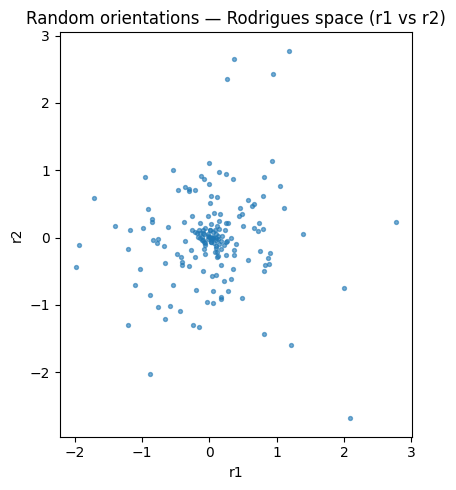

In [43]:
# Visualise 100 random orientations projected via Rodrigues vector
rng = np.random.default_rng(42)
eus = rng.uniform([0, 0, 0], [360, 90, 360], size=(200, 3))

rodrigues = []
for eu in eus:
    rot = Rotation.from_euler(*eu, degrees=True)
    ro = rot.to_rodrigues()
    if np.isfinite(ro).all() and ro[3] < 5:  # skip near-infinite tan values
        rodrigues.append(ro)

rodrigues = np.array(rodrigues)
r_vecs = rodrigues[:, :3] * rodrigues[:, 3:4]  # n * tan(angle/2)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(r_vecs[:, 0], r_vecs[:, 1], s=8, alpha=0.6)
ax.set_xlabel('r1'); ax.set_ylabel('r2')
ax.set_title('Random orientations — Rodrigues space (r1 vs r2)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---
## 3. Crystallography

The `Crystal` class wraps `Cell_T` and supports direct, reciprocal, and Cartesian spaces.

In [44]:
from emsoft.crystallography import Crystal

# Nickel — cubic, a = 0.35236 nm
ni = Crystal(0.35236, 0.35236, 0.35236, 90, 90, 90)
print(ni)
print(f'Volume:  {ni.volume:.6f} nm^3')
print(f'Lattice: {ni.lattice_parameters}')

# Metric tensors
print(f'\nDirect metric tensor:\n{np.round(ni.direct_metric_tensor, 6)}')
print(f'Reciprocal metric tensor:\n{np.round(ni.reciprocal_metric_tensor, 6)}')

Crystal(a=0.35236, b=0.35236, c=0.35236, alpha=90.00, beta=90.00, gamma=90.00)
Volume:  0.043748 nm^3
Lattice: [ 0.35236  0.35236  0.35236 90.      90.      90.     ]

Direct metric tensor:
[[0.124158 0.       0.      ]
 [0.       0.124158 0.      ]
 [0.       0.       0.124158]]
Reciprocal metric tensor:
[[ 8.054281 -0.       -0.      ]
 [-0.        8.054281 -0.      ]
 [-0.       -0.        8.054281]]


In [45]:
# d-spacing for common reflections in cubic Ni
reflections = [(1,1,1), (2,0,0), (2,2,0), (3,1,1)]
print('hkl      d-spacing (nm)   d-spacing (Angstrom)')
for hkl in reflections:
    d = ni.interplanar_spacing(hkl)
    print(f'{hkl}   {d:.5f}          {d*10:.4f}')

hkl      d-spacing (nm)   d-spacing (Angstrom)
(1, 1, 1)   0.20344          2.0344
(2, 0, 0)   0.17618          1.7618
(2, 2, 0)   0.12458          1.2458
(3, 1, 1)   0.10624          1.0624


In [46]:
# Coordinate transforms
# [1,1,0] in direct space -> Cartesian
v_d = [1.0, 1.0, 0.0]
v_c = ni.transform(v_d, 'd', 'c')
print(f'[1,1,0] direct -> Cartesian: {np.round(v_c, 6)} nm')

# Interplanar angle between (100) and (110) in reciprocal space
theta = ni.angle([1, 0, 0], [1, 1, 0], space='r')
print(f'Angle between (100) and (110): {np.degrees(theta):.4f} deg')

# Cross product of two zone axes in direct space
# [100] x [010] = [001]
zp = ni.cross([1, 0, 0], [0, 1, 0], in_space='d', out_space='d')
print(f'[100] x [010] = {np.round(zp, 6)}')

[1,1,0] direct -> Cartesian: [0.35236 0.35236 0.     ] nm
Angle between (100) and (110): 45.0000 deg
[100] x [010] = [-0.       -0.        8.054281]


In [47]:
# Iron (BCC) — tetragonally distorted example (alpha-Fe is actually cubic)
# Hexagonal titanium — a=0.29508, c=0.46855 nm
ti = Crystal(0.29508, 0.29508, 0.46855, 90, 90, 120)
print(ti)
print(f'Ti volume: {ti.volume:.6f} nm^3')
print(f'Ti c/a ratio: {0.46855/0.29508:.4f}')

# Basal plane normal: [0001] in direct space
d_basal = ti.interplanar_spacing([0, 0, 1])  # (0002) for hexagonal
d_prism = ti.interplanar_spacing([1, 0, 0])  # (1010)
print(f'Basal d-spacing (0001): {d_basal:.5f} nm')
print(f'Prism d-spacing (1010): {d_prism:.5f} nm')

Crystal(a=0.29508, b=0.29508, c=0.46855, alpha=90.00, beta=90.00, gamma=120.00)
Ti volume: 0.035332 nm^3
Ti c/a ratio: 1.5879
Basal d-spacing (0001): 0.46855 nm
Prism d-spacing (1010): 0.25555 nm


---
## 4. Symmetry and Space Groups

In [48]:
from emsoft.symmetry import SpaceGroup

# FCC Ni — space group 225 (Fm-3m)
sg225 = SpaceGroup(225)
print(sg225)
print(f'Crystal system: {sg225.crystal_system}')
print(f'Centrosymmetric: {sg225.is_centrosymmetric}')
print(f'Point group order: {sg225.order}')

# Check which reflections are allowed (systematic absences)
print()
print('FCC extinction rule (all indices same parity for allowed):')
for hkl in [(1,1,1), (2,0,0), (1,0,0), (1,1,0), (2,2,0), (1,1,2)]:
    allowed = sg225.is_reflection_allowed(hkl)
    print(f'  {hkl}: {"allowed" if allowed else "FORBIDDEN"}')

SpaceGroup(225, system=Cubic)
Crystal system: Cubic
Centrosymmetric: True
Point group order: 192

FCC extinction rule (all indices same parity for allowed):
  (1, 1, 1): allowed
  (2, 0, 0): allowed
  (1, 0, 0): FORBIDDEN
  (1, 1, 0): FORBIDDEN
  (2, 2, 0): allowed
  (1, 1, 2): FORBIDDEN


In [49]:
# Equivalent positions (orbit) for a general position in Fm-3m
orbit = sg225.calc_orbit([0.1, 0.2, 0.3])
print(f'General position orbit in Fm-3m: {len(orbit)} equivalent positions')
for pos in orbit[:8]:   # show first 8
    print(f'  {np.round(pos, 4)}')
print('  ...')

# Special position (on the corner) -> fewer equivalents
orbit_sp = sg225.calc_orbit([0.0, 0.0, 0.0])
print(f'\nSpecial position [0,0,0] orbit: {len(orbit_sp)} positions')
for pos in orbit_sp:
    print(f'  {np.round(pos, 4)}')

General position orbit in Fm-3m: 96 equivalent positions
  [0.1 0.2 0.3]
  [0.1 0.7 0.8]
  [0.6 0.2 0.8]
  [0.9 0.8 0.3]
  [0.9 0.2 0.7]
  [0.3 0.1 0.2]
  [0.2 0.1 0.7]
  [0.9 0.8 0.7]
  ...

Special position [0,0,0] orbit: 4 positions
  [0. 0. 0.]
  [0.  0.5 0.5]
  [0.5 0.  0.5]
  [0.5 0.5 0. ]


In [50]:
# Equivalent reflections (star) for (111) in Fm-3m
star = sg225.calc_star([1, 1, 1])
print(f'Star of (111) in Fm-3m: {len(star)} equivalent reflections')
for h in star:
    print(f'  {h}')

Star of (111) in Fm-3m: 8 equivalent reflections
  [1. 1. 1.]
  [-1.  1.  1.]
  [-1. -1. -1.]
  [-1. -1.  1.]
  [ 1. -1. -1.]
  [ 1. -1.  1.]
  [ 1.  1. -1.]
  [-1.  1. -1.]


In [51]:
# Compare a few space groups
sgs = [
    (1,   'P1    — triclinic'),
    (2,   'P-1   — triclinic centrosymmetric'),
    (4,   'P2_1  — monoclinic'),
    (62,  'Pnma  — orthorhombic'),
    (194, 'P6_3/mmc — hexagonal (Ti)'),
    (225, 'Fm-3m — cubic FCC (Ni)'),
    (229, 'Im-3m — cubic BCC (Fe)'),
]

print(f'{"SG":<5} {"Crystal system":<15} {"Centrosymm":<12} {"Order"}')
print('-' * 50)
for num, name in sgs:
    sg = SpaceGroup(num)
    print(f'{num:<5} {sg.crystal_system:<15} {str(sg.is_centrosymmetric):<12} {sg.order}')

SG    Crystal system  Centrosymm   Order
--------------------------------------------------
1     Triclinic       False        1
2     Triclinic       True         2
4     Monoclinic      False        2
62    Orthorhombic    True         8
194   Hexagonal       True         24
225   Cubic           True         192
229   Cubic           True         96


---
## 5. Diffraction — Structure Factors and Extinction Distances

In [52]:
from emsoft.crystallography import Crystal
from emsoft.symmetry import SpaceGroup
from emsoft.diffraction import Diffraction

# Set up Ni crystal with atoms
ni = Crystal(0.35236, 0.35236, 0.35236, 90, 90, 90)
sg = SpaceGroup(225)  # Fm-3m
ni.setup_atoms(sg, [
    (28, 0.0, 0.0, 0.0, 1.0, 0.004)  # Ni at origin, occupancy=1, DW=0.004 nm^2
])

# Create Diffraction object at 200 keV
diff = Diffraction(200.0, ni)

# MUST set the scattering method before CalcUcg to get absorption (xgp, Ucg_imag).
# 'WK' = Weickenmeier-Kohl (includes imaginary/absorptive part)
# 'DT' = Doyle-Turner (real part only, xgp will be 1e8 sentinel)
diff.set_method('WK')

print(diff)
print(f'Accelerating voltage: {diff.voltage:.1f} kV')
print(f'Relativistic wavelength: {diff.wavelength*100:.4f} pm')
print(f'Relativistic correction gamma: {diff.relativistic_correction:.6f}')
print(f'Interaction constant sigma: {diff.sigma:.4f} V^-1 nm^-1')

Diffraction(voltage=200.0 keV)
Accelerating voltage: 200.0 kV
Relativistic wavelength: 0.2508 pm
Relativistic correction gamma: 1.391390
Interaction constant sigma: 0.0073 V^-1 nm^-1


In [53]:
# Structure factors for common Ni reflections
reflections = [(1,1,1), (2,0,0), (2,2,0), (3,1,1), (2,2,2), (4,0,0)]

print(f'{"hkl":<10} {"xg (nm)":<12} {"xgp (nm)":<12} {"Ucg real":<12} {"Ucg imag":<12}')
print('-' * 60)
for hkl in reflections:
    sf = diff.calc_structure_factor(ni, hkl)
    print(f'{str(hkl):<10} {sf["xg"]:<12.2f} {sf["xgp"]:<12.2f} '
          f'{sf["Ucg_real"]:<12.5f} {sf["Ucg_imag"]:<12.5f}')

hkl        xg (nm)      xgp (nm)     Ucg real     Ucg imag    
------------------------------------------------------------
(1, 1, 1)  34.46        735.25       11.57109     0.54235     
(2, 0, 0)  39.58        785.13       10.07597     0.50790     
(2, 2, 0)  56.84        939.05       7.01580      0.42465     
(3, 1, 1)  69.08        1035.57      5.77277      0.38507     
(2, 2, 2)  73.23        1066.38      5.44545      0.37394     
(4, 0, 0)  90.52        1187.61      4.40506      0.33577     


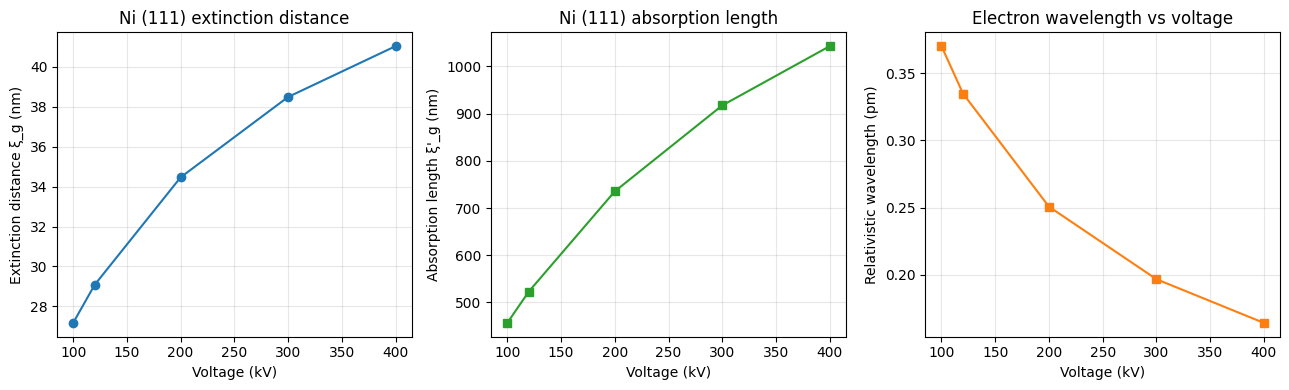

In [54]:
# Plot extinction distance vs voltage
voltages = np.array([100, 120, 200, 300, 400])
xg_111 = []
xgp_111 = []
wavelengths = []

for V in voltages:
    d = Diffraction(float(V), ni)
    d.set_method('WK')
    sf = d.calc_structure_factor(ni, (1, 1, 1))
    xg_111.append(sf['xg'])
    xgp_111.append(sf['xgp'])
    wavelengths.append(d.wavelength * 100)  # pm

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(voltages, xg_111, 'o-')
axes[0].set_xlabel('Voltage (kV)')
axes[0].set_ylabel('Extinction distance ξ_g (nm)')
axes[0].set_title('Ni (111) extinction distance')
axes[0].grid(True, alpha=0.3)

axes[1].plot(voltages, xgp_111, 's-', color='C2')
axes[1].set_xlabel('Voltage (kV)')
axes[1].set_ylabel('Absorption length ξ\'_g (nm)')
axes[1].set_title('Ni (111) absorption length')
axes[1].grid(True, alpha=0.3)

axes[2].plot(voltages, wavelengths, 's-', color='C1')
axes[2].set_xlabel('Voltage (kV)')
axes[2].set_ylabel('Relativistic wavelength (pm)')
axes[2].set_title('Electron wavelength vs voltage')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Lambert Projection

The modified Lambert projection maps a unit hemisphere to a square `[-1, 1]^2`.  
Used internally for master pattern storage and interpolation.

In [55]:
from emsoft.lambert import (
    square_to_sphere, sphere_to_square,
    cube_to_ball, ball_to_cube,
    stereo_forward, stereo_inverse
)

# Square -> Sphere (Lambert)
xy = [0.0, 0.0]       # center of square maps to north pole
xyz = square_to_sphere(xy)
print(f'Square {xy} -> Sphere {np.round(xyz, 6)}')

# Round-trip
xy_back = sphere_to_square(xyz)
print(f'Round-trip back to square: {np.round(xy_back, 10)}')

# A point on the equator
xyz_eq = [1.0, 0.0, 0.0]   # equator at phi=0
xy_eq = sphere_to_square(xyz_eq)
print(f'Equator {xyz_eq} -> Square {np.round(xy_eq, 6)}')

Square [0.0, 0.0] -> Sphere [0. 0. 1.]
Round-trip back to square: [0. 0.]
Equator [1.0, 0.0, 0.0] -> Square [1. 0.]


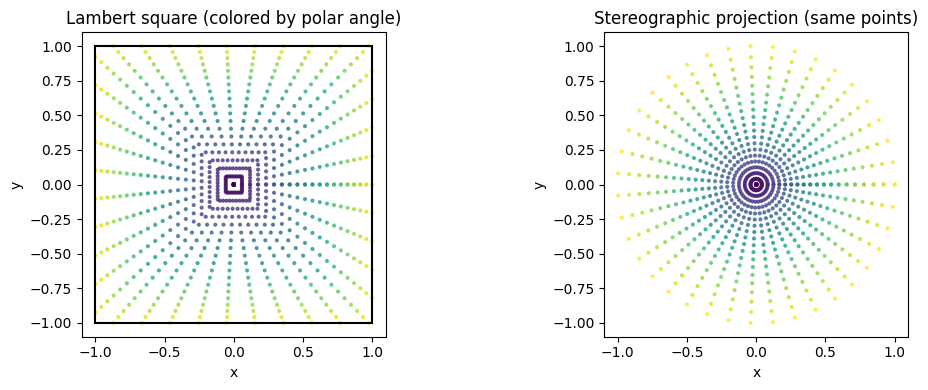

In [56]:
# Visualise the Lambert projection grid
# Sample a regular grid on the hemisphere and project to square
theta = np.linspace(0, np.pi/2, 20)  # polar angle 0..90 deg
phi   = np.linspace(0, 2*np.pi, 40)  # azimuthal
THETA, PHI = np.meshgrid(theta, phi)

xyz_pts = np.column_stack([
    np.sin(THETA.ravel()) * np.cos(PHI.ravel()),
    np.sin(THETA.ravel()) * np.sin(PHI.ravel()),
    np.cos(THETA.ravel())
])

sq_pts = np.array([sphere_to_square(p) for p in xyz_pts])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.scatter(sq_pts[:, 0], sq_pts[:, 1], s=4, c=THETA.ravel(),
            cmap='viridis', alpha=0.7)
ax1.set_xlim(-1.1, 1.1); ax1.set_ylim(-1.1, 1.1)
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_title('Lambert square (colored by polar angle)')
ax1.set_aspect('equal')
ax1.add_patch(plt.Rectangle((-1, -1), 2, 2, fill=False, ec='k', lw=1.5))

# Stereographic projection for comparison
# stereo_forward returns a numpy array of length 2 (not a tuple)
st_pts = []
for p in xyz_pts:
    try:
        st_pts.append(stereo_forward(p))
    except Exception:
        st_pts.append(np.array([np.nan, np.nan]))
st_pts = np.array(st_pts)  # shape (n, 2)

ax2.scatter(st_pts[:, 0], st_pts[:, 1], s=4, c=THETA.ravel(),
            cmap='viridis', alpha=0.7)
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_title('Stereographic projection (same points)')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

---
## 7. Fundamental Zone and MacKenzie Distribution

The `FundamentalZone` class wraps `so3_T` for testing membership and computing theoretical misorientation distributions.

In [57]:
from emsoft.sampling import FundamentalZone

# Cubic m-3m: point group 32
fz_cubic = FundamentalZone(32)
print(fz_cubic)
print(f'Type:  {fz_cubic.fz_type_name}  (code {fz_cubic.fz_type})')
print(f'Order: {fz_cubic.fz_order}')

# Hexagonal 6/mmm: point group 27
fz_hex = FundamentalZone(27)
print()
print(fz_hex)
print(f'Type:  {fz_hex.fz_type_name}  (code {fz_hex.fz_type})')
print(f'Order: {fz_hex.fz_order}')

FundamentalZone(pg=32, type=octahedral)
Type:  octahedral  (code 4)
Order: 0

FundamentalZone(pg=27, type=dihedral)
Type:  dihedral  (code 2)
Order: 6


In [58]:
# Test membership: Rodrigues vector [n1, n2, n3, tan(angle/2)]
# Identity rotation is always inside
print('Identity [0,0,1,0]:', fz_cubic.is_inside([0, 0, 1, 0.0]))

# Small rotation — should be inside
r_small = Rotation.from_axisangle([0, 0, 1], 5, degrees=True)
ro_small = r_small.to_rodrigues()
print(f'5 deg @z  {np.round(ro_small, 4)}: {fz_cubic.is_inside(ro_small)}')

# Large rotation — likely outside
r_large = Rotation.from_axisangle([1, 0, 0], 55, degrees=True)
ro_large = r_large.to_rodrigues()
print(f'55 deg @x {np.round(ro_large, 4)}: {fz_cubic.is_inside(ro_large)}')

Identity [0,0,1,0]: True
5 deg @z  [0.     0.     1.     0.0437]: True
55 deg @x [1.     0.     0.     0.5206]: False


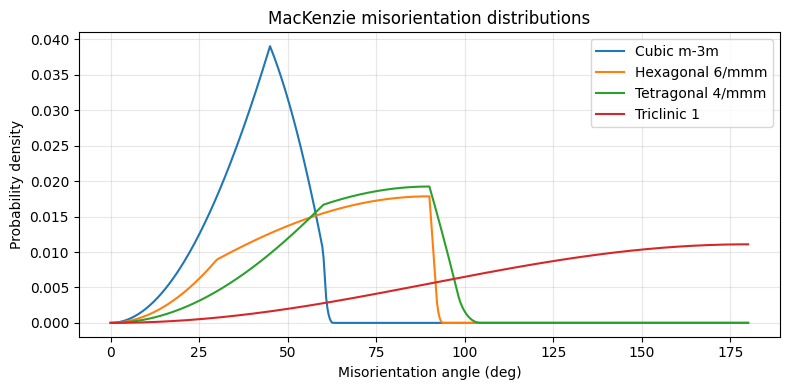

In [59]:
# MacKenzie misorientation distribution
# Theory predicts the probability density of misorientation angles
# for uniformly distributed orientations in a given crystal symmetry

fig, ax = plt.subplots(figsize=(8, 4))

for pg, label, color in [
    (32, 'Cubic m-3m', 'C0'),
    (27, 'Hexagonal 6/mmm', 'C1'),
    (18, 'Tetragonal 4/mmm', 'C2'),
    (1,  'Triclinic 1', 'C3'),
]:
    fz = FundamentalZone(pg)
    angles, mk = fz.mackenzie_distribution(nsteps=500)
    # Normalize to make a proper PDF
    dangle = angles[1] - angles[0]
    mk_norm = mk / (mk.sum() * dangle + 1e-30)
    ax.plot(angles, mk_norm, label=label, color=color)

ax.set_xlabel('Misorientation angle (deg)')
ax.set_ylabel('Probability density')
ax.set_title('MacKenzie misorientation distributions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. EBSD Pattern Simulation

The `EBSDSimulator` interpolates a pre-computed master pattern for any orientation.  
Here we use a **synthetic** master pattern for demonstration.  
With a real `.h5` file, use `emsoft.fileio.read_master_pattern()` instead.

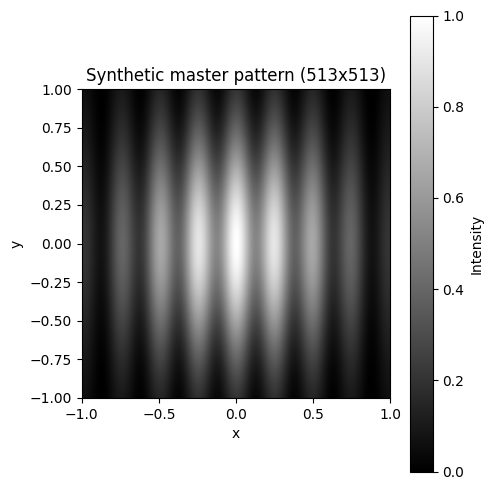

In [60]:
from emsoft.ebsd import EBSDDetector, EBSDSimulator

# --- Build a synthetic master pattern ---
# A real one comes from a Monte Carlo + dynamical simulation (EMEBSD program).
# Here we use a simple anisotropic Gaussian to mimic band structure.
npx = 256
side = 2 * npx + 1
lin = np.linspace(-1, 1, side)
X, Y = np.meshgrid(lin, lin)
R = np.sqrt(X**2 + Y**2)
mp = np.exp(-2 * R**2) + 0.3 * np.cos(8 * np.pi * X) * np.exp(-R**2)
mp = (mp - mp.min()) / (mp.max() - mp.min())

plt.figure(figsize=(5, 5))
plt.imshow(mp, cmap='gray', extent=[-1, 1, -1, 1])
plt.colorbar(label='Intensity')
plt.title(f'Synthetic master pattern ({side}x{side})')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout()
plt.show()

In [61]:
# Set up detector geometry
det = EBSDDetector(
    numsx=160, numsy=120,   # detector pixels
    xpc=0.0, ypc=0.0,       # pattern center at detector center
    delta=50.0,             # pixel size in microns
    thetac=10.0,            # detector camera elevation in degrees
    L=15000.0,              # sample-to-detector distance in microns
    sigma=70.0              # sample tilt in degrees (standard EBSD)
)
print(det)

# Create simulator from the synthetic master pattern
sim = EBSDSimulator(mp, mp, npx=npx)  # same pattern for N and S hemisphere
print(sim)

EBSDDetector(160x120)
EBSDSimulator(npx=256)


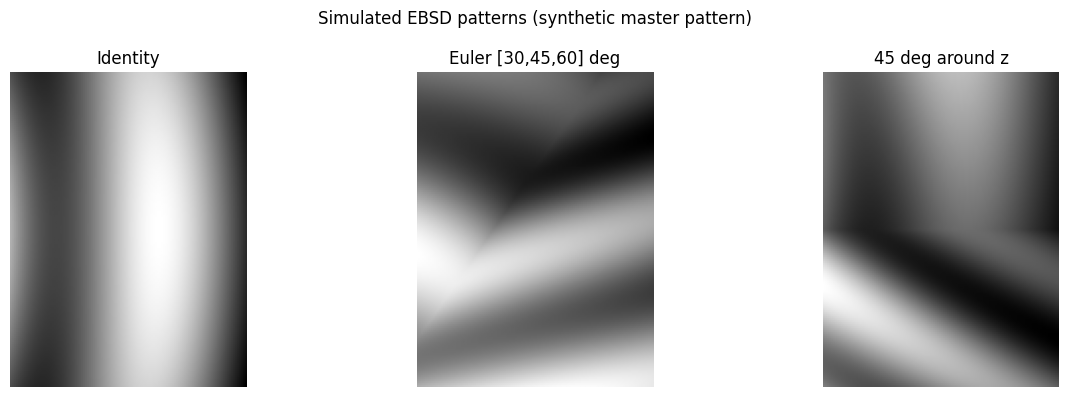

In [62]:
# Compute single pattern — identity orientation
pat_id = sim.compute_pattern(det, quaternion=[1, 0, 0, 0])

# Compute pattern at a specific Euler angle
pat_eu = sim.compute_pattern(det, euler=[30, 45, 60], degrees=True)

# Compute pattern from a Rotation object
r45 = Rotation.from_axisangle([0, 0, 1], 45, degrees=True)
pat_r45 = sim.compute_pattern(det, quaternion=r45.to_quaternion())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, pat, title in zip(axes,
    [pat_id, pat_eu, pat_r45],
    ['Identity', 'Euler [30,45,60] deg', '45 deg around z']):
    ax.imshow(pat.T, cmap='gray', origin='lower')
    ax.set_title(title)
    ax.axis('off')

plt.suptitle('Simulated EBSD patterns (synthetic master pattern)')
plt.tight_layout()
plt.show()

Batch output shape: (12, 120, 160)


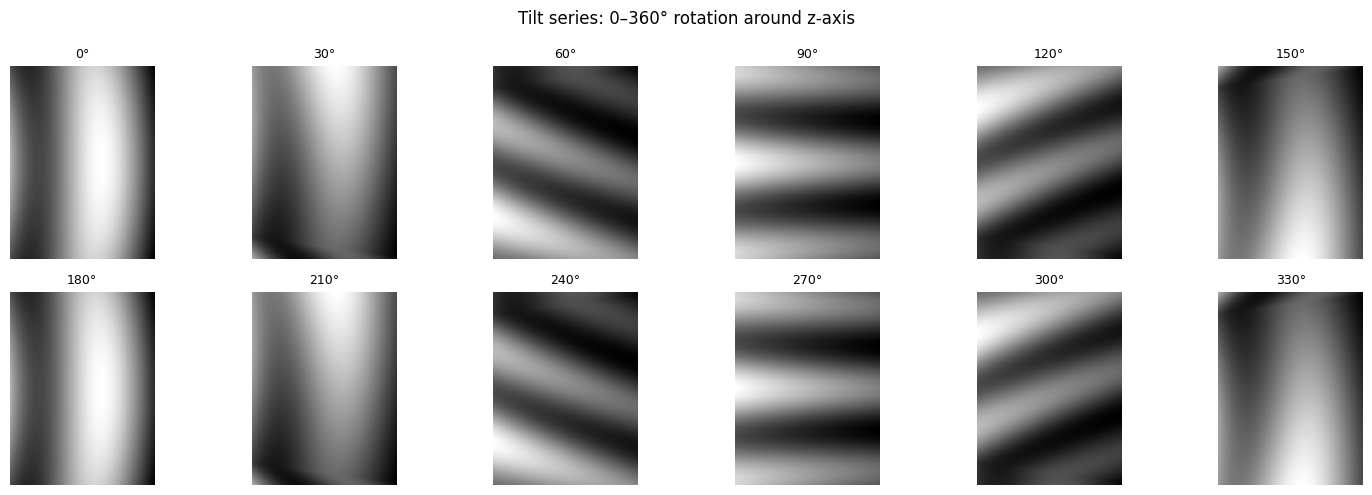

In [63]:
# Batch computation: simulate a tilt series around the z-axis
n_patterns = 12
angles = np.linspace(0, 360, n_patterns, endpoint=False)
quats = np.column_stack([
    np.cos(np.radians(angles)/2),
    np.zeros(n_patterns),
    np.zeros(n_patterns),
    np.sin(np.radians(angles)/2)
])

patterns = sim.compute_patterns(det, quaternions=quats)  # shape (12, numsy, numsx)
print(f'Batch output shape: {patterns.shape}')

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(patterns[i].T, cmap='gray', origin='lower')
    ax.set_title(f'{angles[i]:.0f}°', fontsize=9)
    ax.axis('off')

plt.suptitle('Tilt series: 0–360° rotation around z-axis')
plt.tight_layout()
plt.show()

---
## 9. Loading from .xtal Files

If you have an EMsoftOO crystal structure file (`.xtal`) or master pattern (`.h5`), use `emsoft.fileio`.

In [64]:
from emsoft.fileio import read_xtal, CRYSTAL_SYSTEM_NAMES, ELEMENT_SYMBOLS

xtal_path = 'Ni'  # resolved via EMsoftConfig.json
data = read_xtal(xtal_path)

print(f"Material: space group {data['space_group_number']}")
print(f"Crystal system: {data['crystal_system_name']}")
a, b, c, al, be, ga = data['lattice_parameters']
print(f"Lattice: a={a:.5f} b={b:.5f} c={c:.5f} nm")
print(f"         alpha={al:.2f} beta={be:.2f} gamma={ga:.2f} deg")
print(f"Atom types: {[ELEMENT_SYMBOLS[z] for z in data['atom_types']]}")
print(f"Atom data (x, y, z, occ, DW):\n{data['atom_data']}")

#--- or load directly as a Crystal object ---
from emsoft.crystallography import Crystal
ni = Crystal.from_file(xtal_path)
print(ni)
print(f'Volume: {ni.volume:.6f} nm^3')

#print('Uncomment the lines above and set xtal_path to your .xtal file.')

Material: space group 225
Crystal system: Cubic
Lattice: a=0.35236 b=0.35236 c=0.35236 nm
         alpha=90.00 beta=90.00 gamma=90.00 deg
Atom types: ['Ni']
Atom data (x, y, z, occ, DW):
[[0.     0.     0.     1.     0.0035]]
Crystal(a=0.35236, b=0.35236, c=0.35236, alpha=90.00, beta=90.00, gamma=90.00)
Volume: 0.043748 nm^3


Master pattern npx=500, voltage=20.0 keV
mLPNH shape: (1, 11, 1001, 1001)


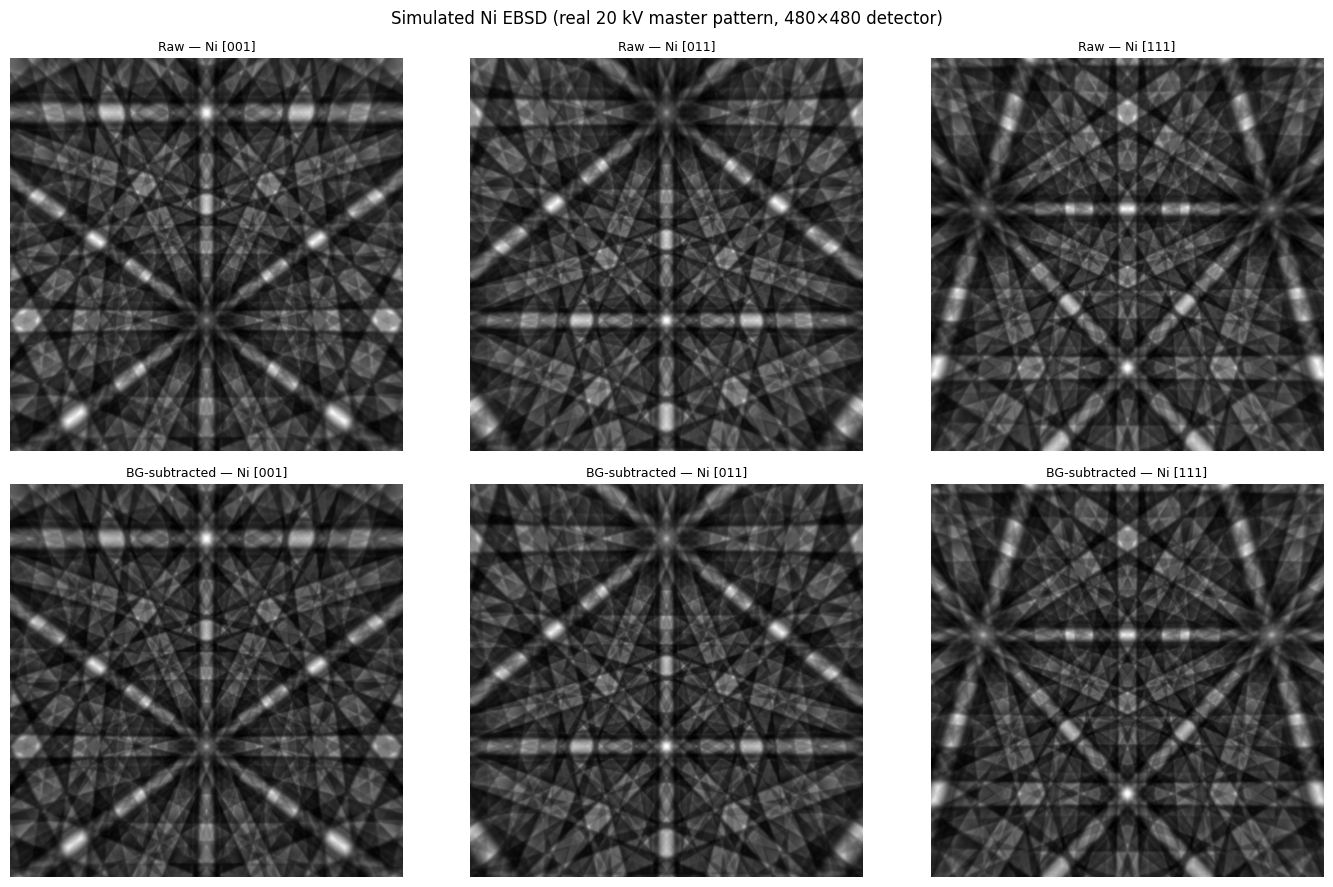

In [65]:
# Loading a master pattern from an HDF5 file
from emsoft.fileio import read_master_pattern
from emsoft.ebsd import EBSDSimulator, EBSDDetector
from scipy.ndimage import gaussian_filter
#"C:\Users\westraadt.1\Software\EMSOFT\EMsoftData\TestWindows\Ni-master-20kV.h5"
mp_data = read_master_pattern('./TestWindows/Ni-master-20kV')  # resolved via EMsoftConfig.json
print(f"Master pattern npx={mp_data['npx']}, voltage={mp_data['voltage']} keV")
print(f"mLPNH shape: {mp_data['mLPNH'].shape}")

sim_ni = EBSDSimulator(mp_data['mLPNH'], mp_data['mLPSH'])

# Typical EBSD detector: 480x480, 50 µm pixels, L=15000 µm (15 mm camera length)
det_ni = EBSDDetector(480, 480, xpc=0.0, ypc=0.0, delta=50.0, thetac=10.0, L=15000.0)

def bg_subtract(pat, sigma_frac=0.08):
    """Divide by Gaussian background; return [0,1]-normalised result."""
    sigma = max(pat.shape) * sigma_frac
    bg = gaussian_filter(pat.astype(float), sigma=sigma)
    eq = pat / (bg + 1e-6)
    eq = (eq - eq.min()) / (eq.max() - eq.min() + 1e-10)
    return eq

# Simulate three low-index zone-axis orientations
orientations = [
    ([0.0,   0.0,  0.0], '[001]'),
    ([0.0,  45.0,  0.0], '[011]'),
    ([0.0,  35.26, 45.0], '[111]'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for col, (euler, label) in enumerate(orientations):
    pat = sim_ni.compute_pattern(det_ni, euler=euler, degrees=True)

    # Row 0: raw integrated intensity (sums all energy bins)
    axes[0, col].imshow(pat, cmap='gray', origin='lower')
    axes[0, col].set_title(f'Raw — Ni {label}', fontsize=9)
    axes[0, col].axis('off')

    # Row 1: background-subtracted → reveals Kikuchi bands
    axes[1, col].imshow(bg_subtract(pat), cmap='gray', origin='lower')
    axes[1, col].set_title(f'BG-subtracted — Ni {label}', fontsize=9)
    axes[1, col].axis('off')

fig.suptitle('Simulated Ni EBSD (real 20 kV master pattern, 480×480 detector)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 10. Dictionary Indexing Workflow

`emsoft.indexing` provides pure-numpy pattern matching, CI, ADP, and KAM maps.

In [66]:
from emsoft.indexing import (
    normalize_patterns, circular_mask,
    match_patterns, confidence_index,
    adp_map, convert_pattern_center
)

# --- Simulate a small dictionary ---
rng = np.random.default_rng(0)
n_dict = 500
n_exp  = 20

dict_quats = np.zeros((n_dict, 4))
angles_d = rng.uniform(0, 2*np.pi, n_dict)
dict_quats[:, 0] = np.cos(angles_d / 2)
dict_quats[:, 3] = np.sin(angles_d / 2)

dict_pats = sim.compute_patterns(det, quaternions=dict_quats)
dict_pats = dict_pats.reshape(n_dict, -1).astype(np.float64)

# Circular mask and normalize
mask = circular_mask(det.numsx, det.numsy).ravel()
dict_pats = dict_pats * mask
dict_pats = normalize_patterns(dict_pats)

print(f'Dictionary: {dict_pats.shape}')

Dictionary: (500, 19200)


In [67]:
# Experimental patterns = dictionary entries + a little noise (known answers)
true_indices = rng.integers(0, n_dict, n_exp)
exp_pats = dict_pats[true_indices] + rng.normal(0, 0.02, (n_exp, dict_pats.shape[1]))
exp_pats = normalize_patterns(exp_pats)

# Match against dictionary
result = match_patterns(exp_pats, dict_pats, n_top=5)
top_indices = result['indices']
top_dp      = result['dot_products']

# Accuracy: how many best matches are correct?
correct = np.sum(top_indices[:, 0] == true_indices)
print(f'Indexing accuracy (top-1): {correct}/{n_exp} = {correct/n_exp*100:.0f}%')

# Confidence index
ci = confidence_index(top_dp)
print(f'Mean CI: {ci.mean():.4f}  (range {ci.min():.4f} – {ci.max():.4f})')

Indexing accuracy (top-1): 6/20 = 30%
Mean CI: 0.0001  (range 0.0000 – 0.0011)


In [68]:
# Pattern center conversion between vendor conventions
# EMsoft uses [xpc, ypc, L] in pixels and microns
# EDAX/TSL, Oxford, Bruker use fractional coordinates

numsx, numsy, delta = 480, 480, 50.0  # 480x480 detector, 50 µm pixels
pc_emsoft = np.array([0.0, 0.0, 15000.0])  # centered, 15 mm camera length

for vendor in ['EDAX', 'Oxford', 'Bruker']:
    pc_v = convert_pattern_center(pc_emsoft, 'EMsoft', vendor, delta, numsx, numsy)
    pc_back = convert_pattern_center(pc_v, vendor, 'EMsoft', delta, numsx, numsy)
    print(f'EMsoft -> {vendor}: {np.round(pc_v, 5)} -> back: {np.round(pc_back, 3)}')

EMsoft -> EDAX: [0.5   0.5   0.625] -> back: [    0.     0. 15000.]
EMsoft -> Oxford: [0.5   0.5   0.625] -> back: [    0.     0. 15000.]
EMsoft -> Bruker: [0.5   0.5   0.625] -> back: [    0.     0. 15000.]


---
## 11. Single-Pattern PC / Orientation Refinement

Given one experimental EBSD pattern, we can refine both the **pattern centre** (PC) and the **crystal orientation** simultaneously using `scipy.optimize.minimize`.

The objective is to **maximise the normalised dot product (NDP)** between the experimental pattern and a pattern simulated at the current parameter guess.

Six free parameters:
| Parameter | Meaning |
|-----------|---------|
| φ₁, Φ, φ₂ | Bunge Euler angles (degrees) |
| xpc, ypc | Pattern centre shifts (pixels) |
| L | Camera length (µm) |

This pure-Python approach works directly with the `emsoft` bindings — no Fortran EMEBSDDI program required.

True Euler   : [25.0, 38.0, 52.0] deg
True PC      : xpc=3.0, ypc=-2.0, L=15200.0 µm
Pattern noise: sigma=0.1058, SNR=29.9 dB

Starting guess: Euler=[27.0, 40.0, 50.0], xpc=4.0, ypc=-3.0, L=15100.0
Initial NDP  : 0.903089

── Refinement result ──────────────────────────────────
Converged    : True  (633 iterations, 985 evaluations)
Final NDP    : 0.999933

Parameter        True    Refined      Error
---------------------------------------------
phi1 (°)       25.000     25.013     +0.013
Phi (°)        38.000     38.004     +0.004
phi2 (°)       52.000     51.993     -0.007
xpc (px)        3.000      3.052     +0.052
ypc (px)       -2.000     -2.007     -0.007
L (µm)      15200.000  15200.549     +0.549


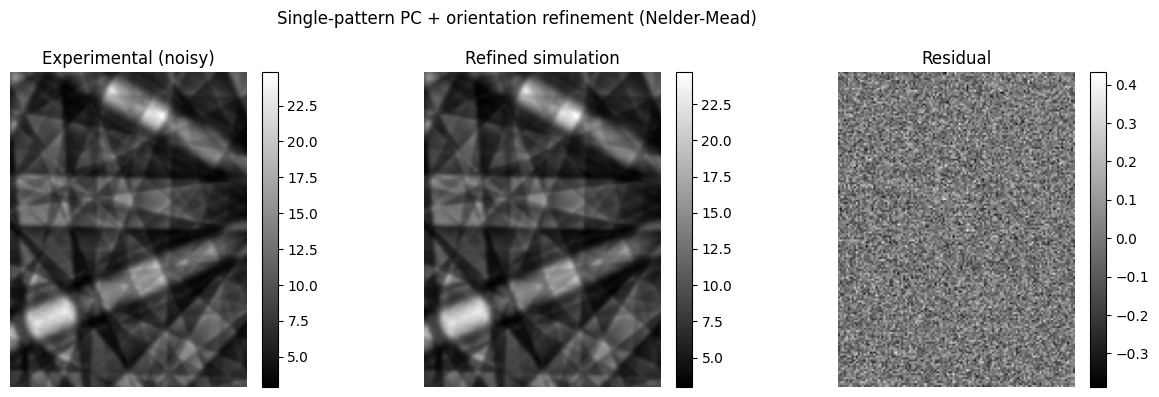

In [69]:
from scipy.optimize import minimize
from emsoft.ebsd import EBSDDetector, EBSDSimulator
from emsoft.indexing import normalize_patterns, circular_mask

# ── 1. Synthetic "experimental" pattern ──────────────────────────────────────
# Use the master pattern already loaded in the notebook (mp / sim from section 8).
# True PC and orientation — what we want the optimizer to recover.
true_euler = [25.0, 38.0, 52.0]   # degrees
true_xpc, true_ypc, true_L = 3.0, -2.0, 15200.0

true_det = EBSDDetector(160, 120, xpc=true_xpc, ypc=true_ypc,
                        delta=50.0, thetac=10.0, L=true_L)
exp_pattern = sim_ni.compute_pattern(true_det, euler=true_euler, degrees=True)

# Add realistic noise (SNR ~ 30 dB) and flatten
rng = np.random.default_rng(7)
noise_sigma = exp_pattern.std() * 0.032
exp_noisy = exp_pattern + rng.normal(0, noise_sigma, exp_pattern.shape)

mask2d = circular_mask(160, 120)
exp_flat = (exp_noisy * mask2d).ravel().astype(np.float64)
exp_norm = normalize_patterns(exp_flat[np.newaxis])[0]

print(f'True Euler   : {true_euler} deg')
print(f'True PC      : xpc={true_xpc}, ypc={true_ypc}, L={true_L} µm')
print(f'Pattern noise: sigma={noise_sigma:.4f}, SNR={20*np.log10(exp_pattern.std()/noise_sigma):.1f} dB')


# ── 2. Objective function ─────────────────────────────────────────────────────
def neg_ndp(params):
    """Return -(normalised dot product) between experimental and simulated pattern."""
    phi1, Phi, phi2, xpc, ypc, L = params

    # Build detector with current PC guess
    det_trial = EBSDDetector(160, 120, xpc=xpc, ypc=ypc,
                             delta=50.0, thetac=10.0, L=L)
    pat = sim_ni.compute_pattern(det_trial, euler=[phi1, Phi, phi2], degrees=True)

    sim_flat = (pat * mask2d).ravel().astype(np.float64)
    sim_norm = normalize_patterns(sim_flat[np.newaxis])[0]

    ndp = float(exp_norm @ sim_norm)   # already unit-normalised
    return -ndp


# ── 3. Starting guess (perturbed from truth) ──────────────────────────────────
x0 = [true_euler[0] + 2, true_euler[1] + 2, true_euler[2] - 2,
      true_xpc + 1, true_ypc - 1, true_L - 100]

print(f'\nStarting guess: Euler={x0[:3]}, xpc={x0[3]}, ypc={x0[4]}, L={x0[5]}')
print(f'Initial NDP  : {-neg_ndp(x0):.6f}')

# ── 4. Nelder-Mead optimisation ───────────────────────────────────────────────
# Initial simplex step sizes: ~1 deg for angles, ~2 px for PC, ~200 µm for L
initial_simplex = np.tile(x0, (7, 1))
for i in range(6):
    step = [1.0, 1.0, 1.0, 2.0, 2.0, 200.0][i]
    initial_simplex[i + 1, i] += step

result = minimize(
    neg_ndp, x0,
    method='Nelder-Mead',
    options=dict(
        xatol=1e-3, fatol=1e-5,
        maxiter=10000,
        initial_simplex=initial_simplex
    )
)

phi1_r, Phi_r, phi2_r, xpc_r, ypc_r, L_r = result.x

print(f'\n── Refinement result ──────────────────────────────────')
print(f'Converged    : {result.success}  ({result.nit} iterations, {result.nfev} evaluations)')
print(f'Final NDP    : {-result.fun:.6f}')
print()
print(f'{"Parameter":<10} {"True":>10} {"Refined":>10} {"Error":>10}')
print('-' * 45)
labels = ['phi1 (°)', 'Phi (°)', 'phi2 (°)', 'xpc (px)', 'ypc (px)', 'L (µm)']
trues  = true_euler + [true_xpc, true_ypc, true_L]
refs   = [phi1_r, Phi_r, phi2_r, xpc_r, ypc_r, L_r]
for lbl, tv, rv in zip(labels, trues, refs):
    print(f'{lbl:<10} {tv:>10.3f} {rv:>10.3f} {rv-tv:>+10.3f}')


# ── 5. Visual comparison ──────────────────────────────────────────────────────
det_ref = EBSDDetector(160, 120, xpc=xpc_r, ypc=ypc_r, delta=50.0, thetac=10.0, L=L_r)
pat_ref = sim_ni.compute_pattern(det_ref, euler=[phi1_r, Phi_r, phi2_r], degrees=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, pat, title in zip(axes,
        [exp_noisy, pat_ref, exp_noisy - pat_ref],
        ['Experimental (noisy)', 'Refined simulation', 'Residual']):
    im = ax.imshow(pat.T, cmap='gray', origin='lower')
    ax.set_title(title)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Single-pattern PC + orientation refinement (Nelder-Mead)')
plt.tight_layout()
plt.show()